In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

---
---

## 所有機器學習模型的10折結果, 不作特徵選擇, KNN補值

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', knn),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=False, random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', knn),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', knn),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42))])

linr_pipe = Pipeline(steps=[('impute', knn),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)


cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 1) 折線圖：每個 metric 各畫一張
for metric in METRICS:
    plt.figure()
    for name, g in cv_df.groupby('model'):
        g = g.sort_values('fold')
        plt.plot(g['fold'], g[metric], marker='o', label=name)
    plt.xlabel('Fold'); plt.ylabel(metric); plt.title(f'Per-fold {metric}')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

# 2) 盒鬚圖（快速看離散度）
for metric in METRICS:
    plt.figure()
    data = [cv_df[cv_df['model']==m][metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric} distribution across folds')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# 3) 穩定度表：std / IQR / CV（越小越穩）
stab = (cv_df
        .melt(id_vars=['model','fold'], value_vars=METRICS, var_name='metric', value_name='val')
        .groupby(['model','metric'])['val']
        .agg(std='std', iqr=lambda x: np.subtract(*np.percentile(x, [75,25])),
             mean='mean')
        .assign(cv=lambda d: d['std']/d['mean'])
        .reset_index()
       )
# 依每個 metric 排序看最穩的模型
for metric in METRICS:
    print(f"\n[Stability ranking] {metric} (by std asc)")
    print(stab[stab['metric']==metric].sort_values('std')[['model','std','iqr','cv','mean']].to_string(index=False))


---
---

## 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, KNN補值

In [16]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', knn),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=False, random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', knn),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', knn),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42))])

linr_pipe = Pipeline(steps=[('impute', knn),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train, y_train)


[RandomForest] fold=1 acc=0.8651 FAR=0.0684 sens=0.0000 spec=0.9316 GM=0.0000
[RandomForest] fold=2 acc=0.9206 FAR=0.0342 sens=0.3333 spec=0.9658 GM=0.5674
[RandomForest] fold=3 acc=0.8889 FAR=0.0513 sens=0.1111 spec=0.9487 GM=0.3247
[RandomForest] fold=4 acc=0.9280 FAR=0.0342 sens=0.3750 spec=0.9658 GM=0.6018
[RandomForest] fold=5 acc=0.9280 FAR=0.0171 sens=0.1250 spec=0.9829 GM=0.3505
[RandomForest] fold=6 acc=0.9280 FAR=0.0427 sens=0.5000 spec=0.9573 GM=0.6918
[RandomForest] fold=7 acc=0.8800 FAR=0.0598 sens=0.0000 spec=0.9402 GM=0.0000
[RandomForest] fold=8 acc=0.9280 FAR=0.0256 sens=0.2500 spec=0.9744 GM=0.4935
[RandomForest] fold=9 acc=0.9120 FAR=0.0427 sens=0.2500 spec=0.9573 GM=0.4892
[RandomForest] fold=10 acc=0.8880 FAR=0.0598 sens=0.1250 spec=0.9402 GM=0.3428
[RandomForest] MEAN acc=0.9067 FAR=0.0436 sens=0.2069 spec=0.9564 GM=0.3862

[SVC] fold=1 acc=0.9206 FAR=0.0085 sens=0.0000 spec=0.9915 GM=0.0000
[SVC] fold=2 acc=0.9206 FAR=0.0085 sens=0.0000 spec=0.9915 GM=0.0000
[SVC

---
---

## 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, 標準化, KNN補值

In [17]:
class NanStandardScaler(BaseEstimator, TransformerMixin):
    """對每欄以忽略 NaN 的 mean/std 做 z-score，保留 NaN 不改動。"""
    def __init__(self, with_mean=True, with_std=True, eps=1e-12):
        self.with_mean = with_mean
        self.with_std = with_std
        self.eps = eps

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_ = np.nanmean(X, axis=0) if self.with_mean else np.zeros(X.shape[1])
        var = np.nanvar(X, axis=0) if self.with_std else np.ones(X.shape[1])
        self.scale_ = np.sqrt(var)
        self.scale_[~np.isfinite(self.scale_)] = 1.0
        self.scale_ = np.maximum(self.scale_, self.eps)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Z = X.copy()
        if self.with_mean:
            Z = Z - self.mean_
        if self.with_std:
            Z = Z / self.scale_
        return Z
    
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg
scaler = StandardScaler()
knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('pre_scale', NanStandardScaler()),
                           ('impute', knn),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=False, random_state=42))])

xgb_pipe = Pipeline(steps=[('pre_scale', NanStandardScaler()),
                           ('impute', knn),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('pre_scale', NanStandardScaler()),
                                   ('impute', knn),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])

rfc_pipe = Pipeline(steps=[('pre_scale', NanStandardScaler()),
                           ('impute', knn),
                           ('smote', smote),
                           ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('pre_scale', NanStandardScaler()),
                          ('impute', knn),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42))])

linr_pipe = Pipeline(steps=[('pre_scale', NanStandardScaler()),
                            ('impute', knn),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train, y_train)


[RandomForest] fold=1 acc=0.8810 FAR=0.0513 sens=0.0000 spec=0.9487 GM=0.0000
[RandomForest] fold=2 acc=0.9286 FAR=0.0171 sens=0.2222 spec=0.9829 GM=0.4674
[RandomForest] fold=3 acc=0.8889 FAR=0.0598 sens=0.2222 spec=0.9402 GM=0.4571
[RandomForest] fold=4 acc=0.8960 FAR=0.0598 sens=0.2500 spec=0.9402 GM=0.4848
[RandomForest] fold=5 acc=0.9360 FAR=0.0171 sens=0.2500 spec=0.9829 GM=0.4957
[RandomForest] fold=6 acc=0.9200 FAR=0.0513 sens=0.5000 spec=0.9487 GM=0.6887
[RandomForest] fold=7 acc=0.8800 FAR=0.0598 sens=0.0000 spec=0.9402 GM=0.0000
[RandomForest] fold=8 acc=0.9280 FAR=0.0256 sens=0.2500 spec=0.9744 GM=0.4935
[RandomForest] fold=9 acc=0.9040 FAR=0.0342 sens=0.0000 spec=0.9658 GM=0.0000
[RandomForest] fold=10 acc=0.8800 FAR=0.0684 sens=0.1250 spec=0.9316 GM=0.3413
[RandomForest] MEAN acc=0.9042 FAR=0.0444 sens=0.1819 spec=0.9556 GM=0.3429

[SVC] fold=1 acc=0.9206 FAR=0.0085 sens=0.0000 spec=0.9915 GM=0.0000
[SVC] fold=2 acc=0.9206 FAR=0.0085 sens=0.0000 spec=0.9915 GM=0.0000
[SVC

---
---

## 所有機器學習模型10折的結果, 不作特徵選擇, 中位數補值

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', imp),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=False, random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', imp),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', imp),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42))])

linr_pipe = Pipeline(steps=[('impute', imp),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train, y_train)


---
---

## 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, 中位數補值

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', imp),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=False, random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', imp),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', imp),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42))])

linr_pipe = Pipeline(steps=[('impute', imp),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train, y_train)


---
---

## 所有機器學習模型的10折結果, 作缺值, 相關性, KNN補值, 隨機森林特徵選擇test acc最高

Best k (by TEST ACC with SMOTE) = 147
Train ACC = 1.0000, Test ACC = 0.9363


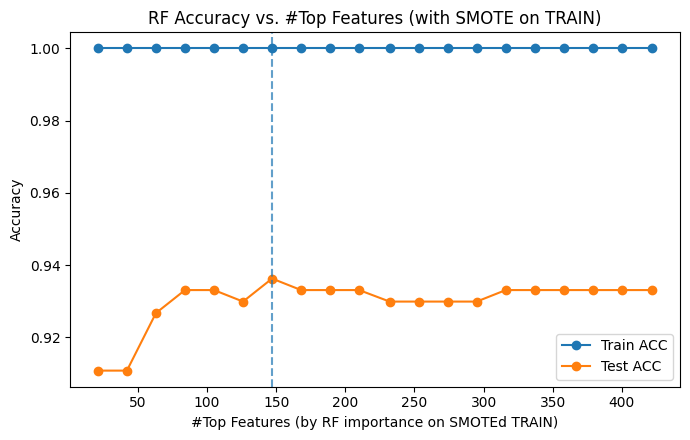

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

knn = KNNImputer(n_neighbors=10, weights='distance')
X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)

minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

rf_base = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  #

p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs, test_accs = [], []

for k in ks:
    cols_k = X_train_imp.columns[feat_order[:k]]
    minority_n_k = int((y_train == 1).sum())
    k_smote_k = max(1, min(5, minority_n_k - 1))
    smote_k = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote_k, random_state=42)
    X_tr_k, y_tr_k = smote_k.fit_resample(X_train_imp[cols_k], y_train)

    rf_k = RandomForestClassifier(n_estimators=600, max_depth=None, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
    rf_k.fit(X_tr_k, y_tr_k)

    y_tr_hat = rf_k.predict(X_train_imp[cols_k])
    y_te_hat = rf_k.predict(X_test_imp[cols_k])

    train_accs.append(accuracy_score(y_train, y_tr_hat))
    test_accs.append(accuracy_score(y_test, y_te_hat))

best_idx = int(np.argmax(test_accs))
best_k = ks[best_idx]
print(f"Best k (by TEST ACC with SMOTE) = {best_k}")
print(f"Train ACC = {train_accs[best_idx]:.4f}, Test ACC = {test_accs[best_idx]:.4f}")

plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs, marker='o', label='Train ACC')
plt.plot(ks, test_accs, marker='o', label='Test ACC')
plt.axvline(best_k, linestyle='--', alpha=0.7)
plt.title('RF Accuracy vs. #Top Features (with SMOTE on TRAIN)')
plt.xlabel('#Top Features (by RF importance on SMOTEd TRAIN)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}
def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

# === 1) 取前 84 個重要特徵（沿用你前面算出的 feat_order / best_k=84）===
best_k = 84
cols_topk = X_train.columns[feat_order[:best_k]].tolist()

# 只保留這 84 欄（保持原始缺失，讓 pipeline 內補值）
X_train_k = X_train[cols_topk].copy()
X_test_k  = X_test[cols_topk].copy()

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svc_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=False, random_state=42))
])

xgb_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, tree_method='hist'))
])

dt_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15,
                                   min_samples_split=20, random_state=42))
])

linr_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())
])

logit_l1_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])



rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

models = [
    ('RandomForest', rfc_pipe),
    ("SVC", svc_pipe),
    ("XGBoost", xgb_pipe),
    ("DecisionTree", dt_pipe),
    ("LinearReg", linr_pipe),
    ("Lasso-Logistic", logit_l1_pipe),
]

all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train_k, y_train)

[RandomForest] fold=1 acc=0.8730 FAR=0.0684 sens=0.1111 spec=0.9316 GM=0.3217
[RandomForest] fold=2 acc=0.8889 FAR=0.0684 sens=0.3333 spec=0.9316 GM=0.5573
[RandomForest] fold=3 acc=0.8651 FAR=0.0940 sens=0.3333 spec=0.9060 GM=0.5495
[RandomForest] fold=4 acc=0.9040 FAR=0.0598 sens=0.3750 spec=0.9402 GM=0.5938
[RandomForest] fold=5 acc=0.8960 FAR=0.0598 sens=0.2500 spec=0.9402 GM=0.4848
[RandomForest] fold=6 acc=0.8800 FAR=0.1026 sens=0.6250 spec=0.8974 GM=0.7489
[RandomForest] fold=7 acc=0.8560 FAR=0.0940 sens=0.1250 spec=0.9060 GM=0.3365
[RandomForest] fold=8 acc=0.9120 FAR=0.0598 sens=0.5000 spec=0.9402 GM=0.6856
[RandomForest] fold=9 acc=0.9040 FAR=0.0598 sens=0.3750 spec=0.9402 GM=0.5938
[RandomForest] fold=10 acc=0.8640 FAR=0.1026 sens=0.3750 spec=0.8974 GM=0.5801
[RandomForest] MEAN acc=0.8843 FAR=0.0769 sens=0.3403 spec=0.9231 GM=0.5452

[SVC] fold=1 acc=0.9048 FAR=0.0342 sens=0.1111 spec=0.9658 GM=0.3276
[SVC] fold=2 acc=0.9127 FAR=0.0342 sens=0.2222 spec=0.9658 GM=0.4633
[SVC

---
---

## 所有機器學習模型的10折結果, 作缺值, 相關性, 中位數補值, 隨機森林特徵選擇test acc最高

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

# ── 1) 8:2 切分（若你已經切好了，這段可略過） ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── 2) 中位數補值：只在訓練集 fit，避免洩漏 ──
imp = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imp.transform(X_test), columns=X_test.columns, index=X_test.index)

# ── 先在「訓練集」做一次 SMOTE，用於計算特徵重要度的排序 ──
minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

# ── 3) 先用全特徵的 RF 在「訓練集」上估重要度並排序 ──
rf_base = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  # 重要度由大到小

# 產生 k 值序列
p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs, test_accs = [], []

# ── 逐個 k：取前 k 特徵 → 在「訓練子集」再做一次 SMOTE → 訓練/評分 ──
for k in ks:
    cols_k = X_train_imp.columns[feat_order[:k]]
    # 對當前特徵子集做 SMOTE（只用訓練集）
    minority_n_k = int((y_train == 1).sum())
    k_smote_k = max(1, min(5, minority_n_k - 1))
    smote_k = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote_k, random_state=42)
    X_tr_k, y_tr_k = smote_k.fit_resample(X_train_imp[cols_k], y_train)

    rf_k = RandomForestClassifier(
        n_estimators=600, max_depth=None,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    )
    rf_k.fit(X_tr_k, y_tr_k)

    y_tr_hat = rf_k.predict(X_train_imp[cols_k])
    y_te_hat = rf_k.predict(X_test_imp[cols_k])

    train_accs.append(accuracy_score(y_train, y_tr_hat))
    test_accs.append(accuracy_score(y_test, y_te_hat))

# 找到 Test ACC 最佳的 k
best_idx = int(np.argmax(test_accs))
best_k = ks[best_idx]
print(f"Best k (by TEST ACC with SMOTE) = {best_k}")
print(f"Train ACC = {train_accs[best_idx]:.4f}, Test ACC = {test_accs[best_idx]:.4f}")

# 繪圖
plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs, marker='o', label='Train ACC')
plt.plot(ks, test_accs, marker='o', label='Test ACC')
plt.axvline(best_k, linestyle='--', alpha=0.7)
plt.title('RF Accuracy vs. #Top Features (with SMOTE on TRAIN)')
plt.xlabel('#Top Features (by RF importance on SMOTEd TRAIN)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}
def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

# === 1) 取前 84 個重要特徵（沿用你前面算出的 feat_order / best_k=84）===
best_k = 84
cols_topk = X_train.columns[feat_order[:best_k]].tolist()

# 只保留這 84 欄（保持原始缺失，讓 pipeline 內補值）
X_train_k = X_train[cols_topk].copy()
X_test_k  = X_test[cols_topk].copy()

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svc_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=False, random_state=42))
])

xgb_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, tree_method='hist'))
])

dt_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15,
                                   min_samples_split=20, random_state=42))
])

linr_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())
])

logit_l1_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])



rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

models = [
    ('RandomForest', rfc_pipe),
    ("SVC", svc_pipe),
    ("XGBoost", xgb_pipe),
    ("DecisionTree", dt_pipe),
    ("LinearReg", linr_pipe),
    ("Lasso-Logistic", logit_l1_pipe),
]


# === 3) 跑 CV（沿用你有動態調 SMOTE k 的 run_cv）===
all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train_k, y_train)

---
---


## 所有機器學習模型的10折結果, 不作缺值, 相關性特徵選擇, KNN補值, 隨機森林特徵選擇test acc最高

Best k (by TEST ACC with SMOTE) = 118
Train ACC = 1.0000, Test ACC = 0.9331


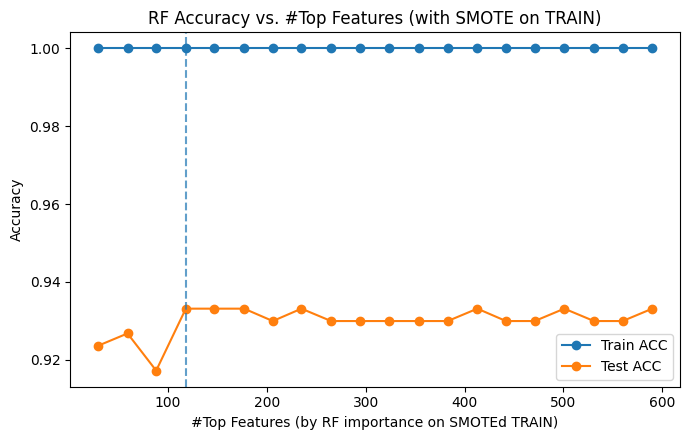

In [22]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

# ── 1) 8:2 切分（若你已經切好了，這段可略過） ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── 2) KNN補值：只在訓練集 fit，避免洩漏 ──
knn = KNNImputer(n_neighbors=10, weights='distance')
X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)

# ── 先在「訓練集」做一次 SMOTE，用於計算特徵重要度的排序 ──
minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

# ── 3) 先用全特徵的 RF 在「訓練集」上估重要度並排序 ──
rf_base = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  # 重要度由大到小

# 產生 k 值序列
p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs, test_accs = [], []

# ── 逐個 k：取前 k 特徵 → 在「訓練子集」再做一次 SMOTE → 訓練/評分 ──
for k in ks:
    cols_k = X_train_imp.columns[feat_order[:k]]
    # 對當前特徵子集做 SMOTE（只用訓練集）
    minority_n_k = int((y_train == 1).sum())
    k_smote_k = max(1, min(5, minority_n_k - 1))
    smote_k = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote_k, random_state=42)
    X_tr_k, y_tr_k = smote_k.fit_resample(X_train_imp[cols_k], y_train)

    rf_k = RandomForestClassifier(
        n_estimators=600, max_depth=None,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    )
    rf_k.fit(X_tr_k, y_tr_k)

    y_tr_hat = rf_k.predict(X_train_imp[cols_k])
    y_te_hat = rf_k.predict(X_test_imp[cols_k])

    train_accs.append(accuracy_score(y_train, y_tr_hat))
    test_accs.append(accuracy_score(y_test, y_te_hat))

# 找到 Test ACC 最佳的 k
best_idx = int(np.argmax(test_accs))
best_k = ks[best_idx]
print(f"Best k (by TEST ACC with SMOTE) = {best_k}")
print(f"Train ACC = {train_accs[best_idx]:.4f}, Test ACC = {test_accs[best_idx]:.4f}")

# 繪圖
plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs, marker='o', label='Train ACC')
plt.plot(ks, test_accs, marker='o', label='Test ACC')
plt.axvline(best_k, linestyle='--', alpha=0.7)
plt.title('RF Accuracy vs. #Top Features (with SMOTE on TRAIN)')
plt.xlabel('#Top Features (by RF importance on SMOTEd TRAIN)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}
def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

# === 1) 取前 84 個重要特徵（沿用你前面算出的 feat_order / best_k=84）===
best_k = 84
cols_topk = X_train.columns[feat_order[:best_k]].tolist()

# 只保留這 84 欄（保持原始缺失，讓 pipeline 內補值）
X_train_k = X_train[cols_topk].copy()
X_test_k  = X_test[cols_topk].copy()

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svc_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=False, random_state=42))
])

xgb_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, tree_method='hist'))
])

dt_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15,
                                   min_samples_split=20, random_state=42))
])

linr_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())
])

logit_l1_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])



rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

models = [
    ('RandomForest', rfc_pipe),
    ("SVC", svc_pipe),
    ("XGBoost", xgb_pipe),
    ("DecisionTree", dt_pipe),
    ("LinearReg", linr_pipe),
    ("Lasso-Logistic", logit_l1_pipe),
]


# === 3) 跑 CV（沿用你有動態調 SMOTE k 的 run_cv）===
all_avg = {}
for name, pipe in models:
    all_avg[name] = run_cv(name, pipe, skf, X_train_k, y_train)

[RandomForest] fold=1 acc=0.8571 FAR=0.0769 sens=0.0000 spec=0.9231 GM=0.0000
[RandomForest] fold=2 acc=0.8730 FAR=0.0855 sens=0.3333 spec=0.9145 GM=0.5521
[RandomForest] fold=3 acc=0.8810 FAR=0.0769 sens=0.3333 spec=0.9231 GM=0.5547
[RandomForest] fold=4 acc=0.8800 FAR=0.0769 sens=0.2500 spec=0.9231 GM=0.4804
[RandomForest] fold=5 acc=0.9120 FAR=0.0513 sens=0.3750 spec=0.9487 GM=0.5965
[RandomForest] fold=6 acc=0.8720 FAR=0.1026 sens=0.5000 spec=0.8974 GM=0.6699
[RandomForest] fold=7 acc=0.8720 FAR=0.0769 sens=0.1250 spec=0.9231 GM=0.3397
[RandomForest] fold=8 acc=0.9120 FAR=0.0513 sens=0.3750 spec=0.9487 GM=0.5965
[RandomForest] fold=9 acc=0.8880 FAR=0.0684 sens=0.2500 spec=0.9316 GM=0.4826
[RandomForest] fold=10 acc=0.8640 FAR=0.0940 sens=0.2500 spec=0.9060 GM=0.4759
[RandomForest] MEAN acc=0.8811 FAR=0.0761 sens=0.2792 spec=0.9239 GM=0.4748

[SVC] fold=1 acc=0.9206 FAR=0.0171 sens=0.1111 spec=0.9829 GM=0.3305
[SVC] fold=2 acc=0.9206 FAR=0.0256 sens=0.2222 spec=0.9744 GM=0.4653
[SVC

---
---

## 隨機森林特徵選擇前處理

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def rf_feature_stability(X: pd.DataFrame, y: pd.Series, k_top: int = 50, n_splits: int = 10, n_repeats: int = 5, knn_k: int = 10):
    feat_names = np.array(X.columns)
    counts = pd.Series(0, index=feat_names, dtype=int)
    imp_sum = pd.Series(0.0, index=feat_names, dtype=float)

    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    total_folds = n_splits * n_repeats

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced')

    for tr_idx, _ in rskf.split(X, y):
        X_tr = X.iloc[tr_idx]
        y_tr = y.iloc[tr_idx]

        imp = KNNImputer(n_neighbors=knn_k, weights='distance')
        X_tr_imp = imp.fit_transform(X_tr)

        rf.fit(X_tr_imp, y_tr)
        importances = pd.Series(rf.feature_importances_, index=feat_names)

        topk = importances.nlargest(k_top).index
        counts[topk] += 1
        imp_sum += importances  # 可用來做平均重要度參考

    stability = counts / total_folds
    imp_mean = imp_sum / total_folds

    out = pd.DataFrame({
        'count_selected': counts,
        'stability': stability,
        'mean_importance': imp_mean
    }).sort_values(['stability','mean_importance'], ascending=False)

    return out, total_folds

out_df, total = rf_feature_stability(X, y, k_top=50, n_splits=10, n_repeats=5, knn_k=10)
# print(out_df.head(20))
# # 例如：選穩定度 >= 0.6 的特徵
# stable_feats = out_df[out_df['stability'] >= 0.6].index.tolist()
RF_KW = dict(
    n_estimators=1000, min_samples_leaf=15, max_depth=6,
    min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced'
)

def eval_topk_by_acc(out_df, X, y, k_grid, test_size=0.2, knn_k=10, random_state=42):
    ranked_feats = out_df.index.tolist()
    max_k = min(max(k_grid), len(ranked_feats))

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    rows = []
    for k in sorted(k for k in k_grid if k <= max_k):
        feats = ranked_feats[:k]

        imputer = KNNImputer(n_neighbors=knn_k, weights='distance')
        X_tr_imp = imputer.fit_transform(X_tr[feats])
        X_te_imp = imputer.transform(X_te[feats])

        rf = RandomForestClassifier(**RF_KW)
        rf.fit(X_tr_imp, y_tr)

        y_tr_pred = rf.predict(X_tr_imp)
        y_te_pred = rf.predict(X_te_imp)

        rows.append({
            'k': k,
            'train_acc': accuracy_score(y_tr, y_tr_pred),
            'test_acc':  accuracy_score(y_te, y_te_pred)
        })

    res = pd.DataFrame(rows).sort_values('k')
    best_idx = res['test_acc'].idxmax()
    best_k = int(res.loc[best_idx, 'k'])
    best_feats = ranked_feats[:best_k]
    return res, best_k, best_feats

k_grid = range(10, 201, 10)
res_df, best_k, best_feats = eval_topk_by_acc(out_df, X, y, k_grid, test_size=0.2, knn_k=10)

print(res_df)
print(f"Best k (by TEST ACC) = {best_k}")

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

METRICS = ['acc','FAR','sensitivity','specificity','GM']
def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg, df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train_k = X_train[best_feats].copy()
X_test_k  = X_test[best_feats].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svc_pipe = Pipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=False, random_state=42))
])

xgb_pipe = Pipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, tree_method='hist'))
])

dt_pipe = Pipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15,
                                   min_samples_split=20, random_state=42))
])

linr_pipe = Pipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())
])

logit_l1_pipe = Pipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])



rfc_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

models = [('RandomForest', rfc_pipe), 
          ("SVC", svc_pipe), 
          ("XGBoost", xgb_pipe), 
          ("DecisionTree", dt_pipe),
          ("LinearReg", linr_pipe),
          ("Lasso-Logistic", logit_l1_pipe),]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train_k, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)
    
cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 1) 折線圖：每個 metric 各畫一張
for metric in METRICS:
    plt.figure()
    for name, g in cv_df.groupby('model'):
        g = g.sort_values('fold')
        plt.plot(g['fold'], g[metric], marker='o', label=name)
    plt.xlabel('Fold'); plt.ylabel(metric); plt.title(f'Per-fold {metric}')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

# 2) 盒鬚圖（快速看離散度）
for metric in METRICS:
    plt.figure()
    data = [cv_df[cv_df['model']==m][metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric} distribution across folds')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# 3) 穩定度表：std / IQR / CV（越小越穩）
stab = (cv_df
        .melt(id_vars=['model','fold'], value_vars=METRICS, var_name='metric', value_name='val')
        .groupby(['model','metric'])['val']
        .agg(std='std', iqr=lambda x: np.subtract(*np.percentile(x, [75,25])),
             mean='mean')
        .assign(cv=lambda d: d['std']/d['mean'])
        .reset_index()
       )
# 依每個 metric 排序看最穩的模型
for metric in METRICS:
    print(f"\n[Stability ranking] {metric} (by std asc)")
    print(stab[stab['metric']==metric].sort_values('std')[['model','std','iqr','cv','mean']].to_string(index=False))


---
---

In [29]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 穩定選特徵 只在X_dev上做
k_top = 50
n_splits = 10
n_repeats = 5
knn_k = 10

feat_names = np.array(X_dev.columns)
counts = pd.Series(0, index=feat_names, dtype=int)   # 被選入前 k_top 的次數
imp_sum = pd.Series(0.0, index=feat_names, dtype=float)

rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced')

for tr_idx, _ in rskf.split(X_dev, y_dev):
    X_tr = X_dev.iloc[tr_idx]
    y_tr = y_dev.iloc[tr_idx]

    imputer = KNNImputer(n_neighbors=knn_k, weights='distance')
    X_tr_imp = imputer.fit_transform(X_tr)

    rf.fit(X_tr_imp, y_tr)
    importances = pd.Series(rf.feature_importances_, index=feat_names)

    topk = importances.nlargest(k_top).index
    counts[topk] += 1
    imp_sum += importances

total_folds = n_splits*n_repeats
stability = counts/total_folds
imp_mean = imp_sum/total_folds

out = pd.DataFrame({'count_selected': counts, 'stability': stability, 'mean_importance': imp_mean}).sort_values(['stability','mean_importance'], ascending=False)

ranked_feats = out.index.tolist()

scorer = make_scorer(roc_auc_score, needs_threshold=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_grid = range(10, 201, 10)
rows = []

for k in k_grid:
    feats = ranked_feats[:k]
    X_sub = X_dev[feats]

    pipe = Pipeline(steps=[('imp', KNNImputer(n_neighbors=10, weights='distance')), 
                           ('rf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced'))])

    cv_scores = cross_val_score(pipe, X_sub, y_dev, cv=skf, scoring=scorer, n_jobs=-1)
    rows.append({'k': k, 'cv_auc_mean': float(np.mean(cv_scores)),
                 'cv_auc_std': float(np.std(cv_scores))})

cv_table = pd.DataFrame(rows).sort_values('k')
best_k = int(cv_table.loc[cv_table['cv_auc_mean'].idxmax(), 'k'])
best_feats = ranked_feats[:best_k]
print(cv_table)
print(f"Best k (by CV ROC-AUC on train_dev) = {best_k}")

# 鎖定最佳k後，在 train_dev 重訓，最後到 test 做一次性評估
final_pipe = Pipeline(steps=[('imp', KNNImputer(n_neighbors=10, weights='distance')),
                             ('rf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1, class_weight='balanced'))])

# 重訓在整個 train_dev 上
X_dev_k  = X_dev[best_feats]
X_test_k = X_test[best_feats]
final_pipe.fit(X_dev_k, y_dev)

# 一次性評估
y_pred = final_pipe.predict(X_test_k)
test_m = compute_metrics(y_test.values, y_pred)
print(test_m)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


      k  cv_auc_mean  cv_auc_std
0    10     0.734860    0.080910
1    20     0.771069    0.033208
2    30     0.797134    0.041506
3    40     0.787689    0.033553
4    50     0.784772    0.032349
5    60     0.788773    0.032071
6    70     0.784575    0.034474
7    80     0.782510    0.030082
8    90     0.783343    0.033613
9   100     0.777300    0.030671
10  110     0.772844    0.037709
11  120     0.769212    0.034886
12  130     0.762695    0.038875
13  140     0.762227    0.035254
14  150     0.761944    0.034351
15  160     0.759735    0.039279
16  170     0.755678    0.040879
17  180     0.753029    0.039624
18  190     0.753856    0.053288
19  200     0.750996    0.049257
Best k (by CV ROC-AUC on train_dev) = 30
{'cm': array([[282,  11],
       [ 18,   3]], dtype=int64), 'acc': 0.9076433121019108, 'FAR': 0.03754266211604096, 'sensitivity': 0.14285714285714285, 'specificity': 0.962457337883959, 'GM': 0.3708017063229269}


[RandomForest] fold=1 train_acc=0.9015 acc=0.8095 FAR=0.1624 sens=0.4444 spec=0.8376 GM=0.6101
[RandomForest] fold=2 train_acc=0.8900 acc=0.8810 FAR=0.1026 sens=0.6667 spec=0.8974 GM=0.7735
[RandomForest] fold=3 train_acc=0.8935 acc=0.8016 FAR=0.1624 sens=0.3333 spec=0.8376 GM=0.5284
[RandomForest] fold=4 train_acc=0.8910 acc=0.8720 FAR=0.1197 sens=0.7500 spec=0.8803 GM=0.8126
[RandomForest] fold=5 train_acc=0.8945 acc=0.8240 FAR=0.1453 sens=0.3750 spec=0.8547 GM=0.5661
[RandomForest] fold=6 train_acc=0.8910 acc=0.8400 FAR=0.1453 sens=0.6250 spec=0.8547 GM=0.7309
[RandomForest] fold=7 train_acc=0.8972 acc=0.8080 FAR=0.1538 sens=0.2500 spec=0.8462 GM=0.4599
[RandomForest] fold=8 train_acc=0.8652 acc=0.8720 FAR=0.1111 sens=0.6250 spec=0.8889 GM=0.7454
[RandomForest] fold=9 train_acc=0.8821 acc=0.9040 FAR=0.0940 sens=0.8750 spec=0.9060 GM=0.8904
[RandomForest] fold=10 train_acc=0.8998 acc=0.7600 FAR=0.2137 sens=0.3750 spec=0.7863 GM=0.5430
[RandomForest] MEAN acc=0.8372 FAR=0.1410 sens=0.

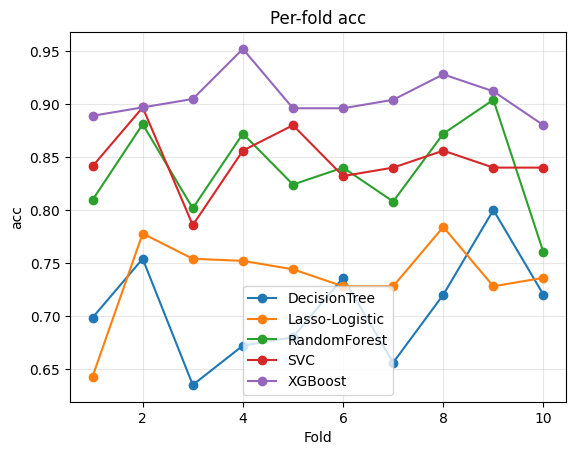

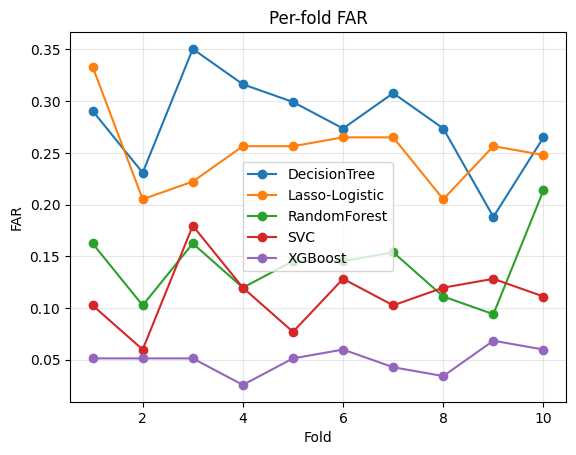

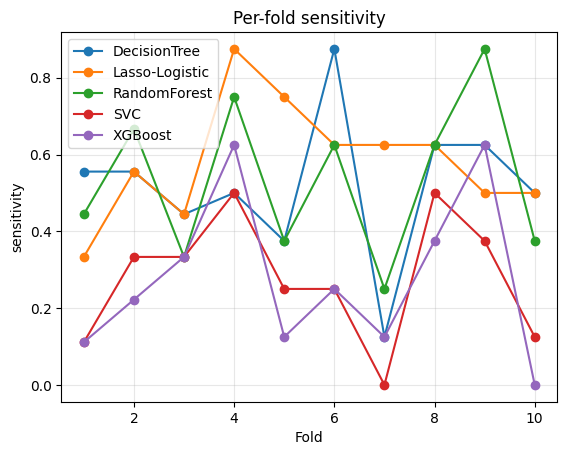

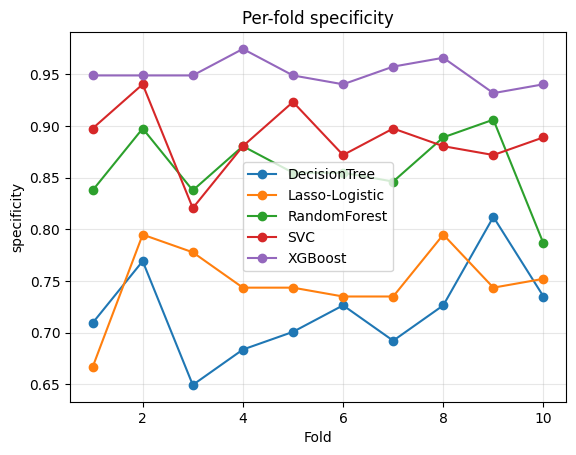

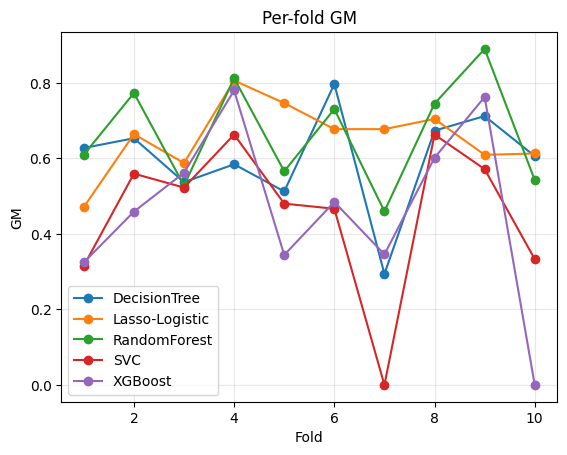

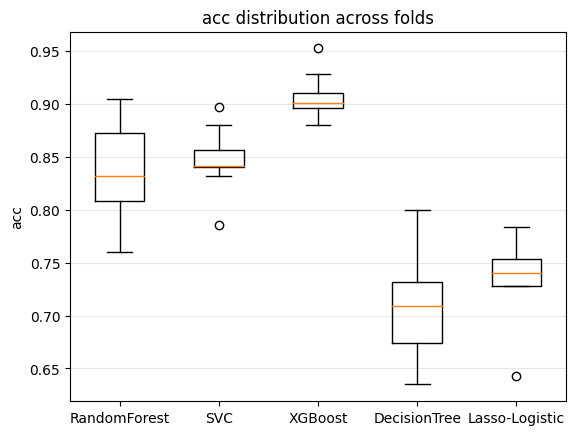

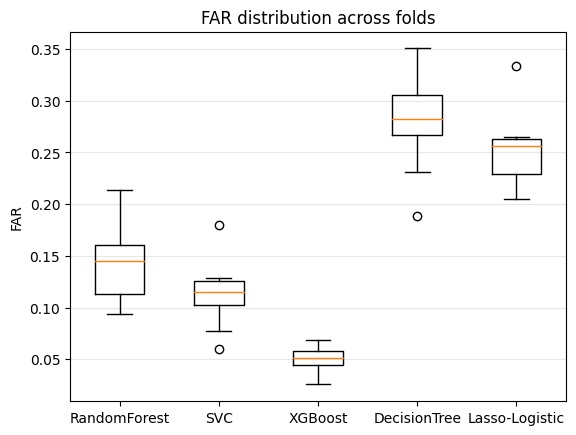

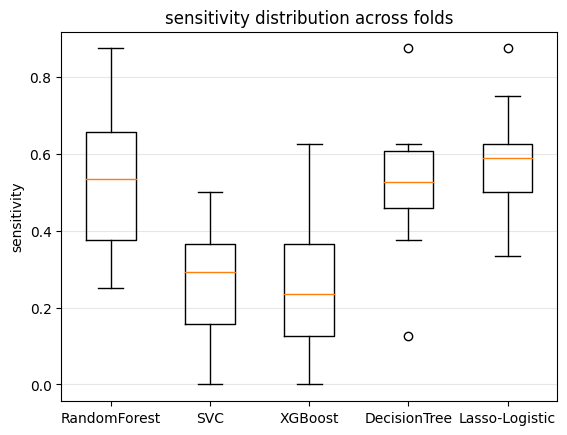

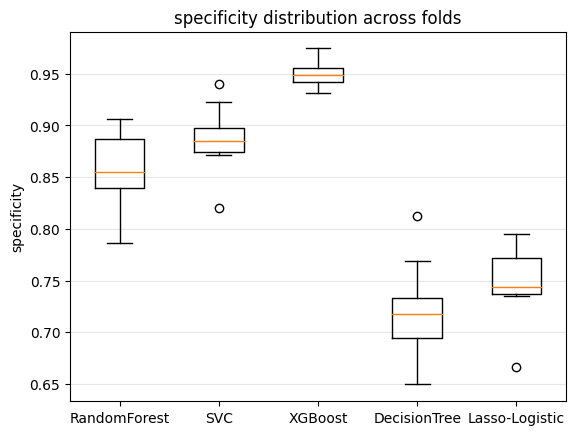

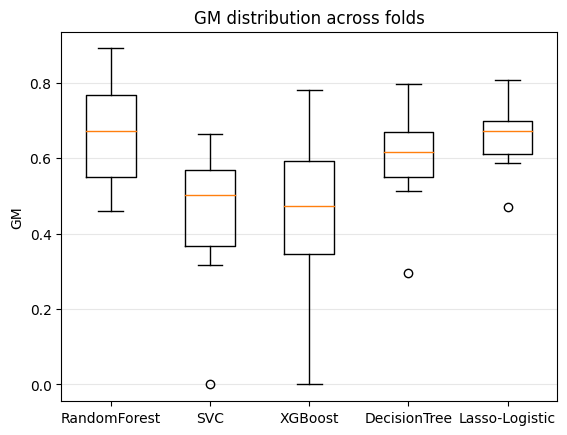


[Stability ranking] acc (by std asc)
         model      std      iqr       cv     mean
       XGBoost 0.020801 0.014190 0.022963 0.905848
           SVC 0.029616 0.016000 0.034975 0.846781
Lasso-Logistic 0.038785 0.025476 0.052593 0.737460
  RandomForest 0.044506 0.063619 0.053161 0.837206
  DecisionTree 0.049282 0.058000 0.069692 0.707130

[Stability ranking] FAR (by std asc)
         model      std      iqr       cv     mean
       XGBoost 0.012613 0.012821 0.254436 0.049573
           SVC 0.032182 0.023504 0.285253 0.112821
  RandomForest 0.035641 0.047009 0.252727 0.141026
Lasso-Logistic 0.036971 0.034188 0.147130 0.251282
  DecisionTree 0.045593 0.038462 0.163131 0.279487

[Stability ranking] sensitivity (by std asc)
         model      std      iqr       cv     mean
Lasso-Logistic 0.154383 0.125000 0.264656 0.583333
           SVC 0.164726 0.208333 0.593015 0.277778
  DecisionTree 0.192678 0.149306 0.371926 0.518056
  RandomForest 0.204549 0.281250 0.384531 0.531944
       XGBo

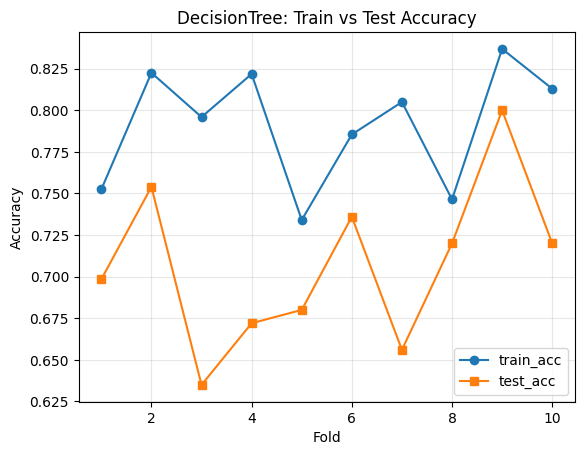

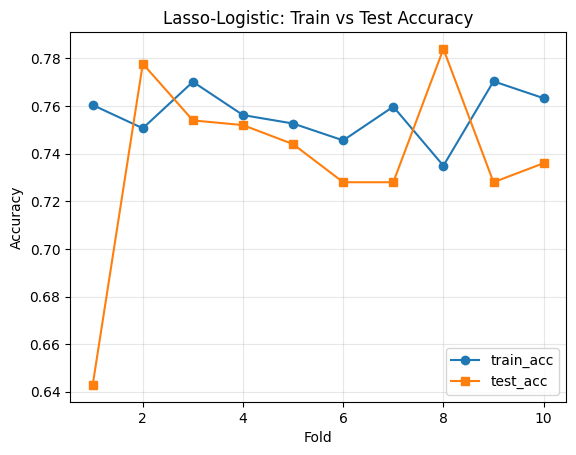

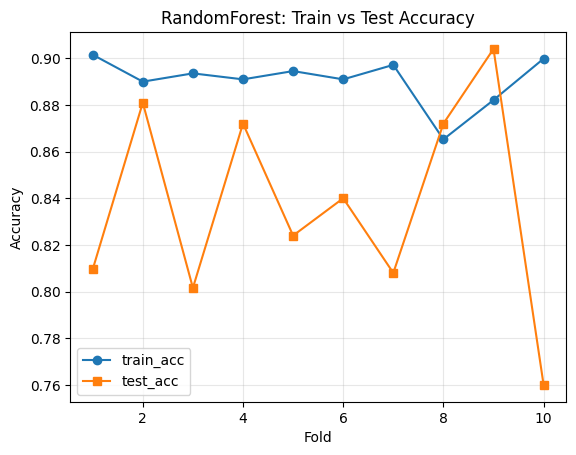

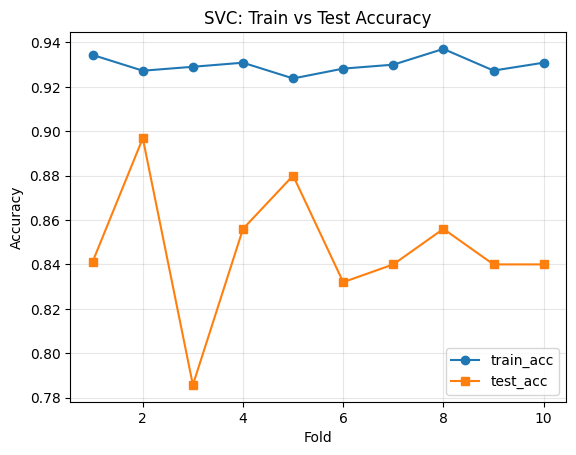

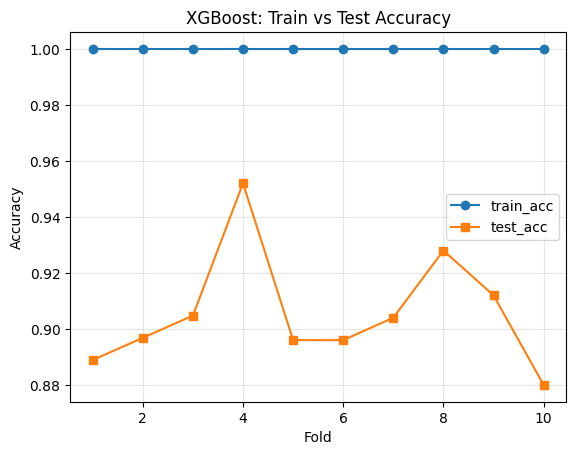

                train_acc  test_acc       gap
model                                        
XGBoost          1.000000  0.905848  0.094152
SVC              0.929857  0.846781  0.083076
RandomForest     0.890575  0.837206  0.053369
Lasso-Logistic   0.756408  0.737460  0.018948
DecisionTree     0.791345  0.707130  0.084215


In [30]:
best_feats = ranked_feats[:best_k]

X_dev_k  = X_dev[best_feats].copy()
X_test_k = X_test[best_feats].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        y_tr_hat = pipe.predict(X_tr)
        train_acc = accuracy_score(y_tr, y_tr_hat)
        y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, 'train_acc':train_acc, 'test_acc':m['acc'], **{k:m[k] for k in METRICS}})
        print(f"[{model_name}] fold={fold} train_acc={train_acc:.4f} acc={m['acc']:.4f} FAR={m['FAR']:.4f} sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    df = pd.DataFrame(fold_metrics)
    avg = {'train_acc':df['train_acc'].mean(), 'test_acc':df['test_acc'].mean(), **{k:df[k].mean() for k in METRICS}}
    gap = avg['train_acc']-avg['test_acc']
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

from imblearn.pipeline import Pipeline

svc_pipe = Pipeline(steps=[('impute', knn), ('scaler', StandardScaler()), ('smote', smote), ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',class_weight='balanced', probability=False, random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

dt_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))])

logit_l1_pipe = Pipeline(steps=[('impute', knn), ('scaler', StandardScaler()), ('smote', smote), ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1))])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", logit_l1_pipe),]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_dev_k, y_dev)
    all_avg[name] = avg
    fold_dfs.append(df)
    
cv_df = pd.concat(fold_dfs, ignore_index=True)

# 1) 折線圖：每個 metric 各畫一張
for metric in METRICS:
    plt.figure()
    for name, g in cv_df.groupby('model'):
        g = g.sort_values('fold')
        plt.plot(g['fold'], g[metric], marker='o', label=name)
    plt.xlabel('Fold'); plt.ylabel(metric); plt.title(f'Per-fold {metric}')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

# 2) 盒鬚圖（快速看離散度）
for metric in METRICS:
    plt.figure()
    data = [cv_df[cv_df['model']==m][metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric} distribution across folds')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# 3) 穩定度表：std / IQR / CV（越小越穩）
stab = (cv_df
        .melt(id_vars=['model','fold'], value_vars=METRICS, var_name='metric', value_name='val')
        .groupby(['model','metric'])['val']
        .agg(std='std', iqr=lambda x: np.subtract(*np.percentile(x, [75,25])),
             mean='mean')
        .assign(cv=lambda d: d['std']/d['mean'])
        .reset_index())

# 依每個 metric 排序看最穩的模型
for metric in METRICS:
    print(f"\n[Stability ranking] {metric} (by std asc)")
    print(stab[stab['metric']==metric].sort_values('std')[['model','std','iqr','cv','mean']].to_string(index=False))

for name, g in cv_df.groupby('model'):
    g = g.sort_values('fold')
    plt.figure()
    plt.plot(g['fold'], g['train_acc'], marker='o', label='train_acc')
    plt.plot(g['fold'], g['test_acc'],  marker='s', label='test_acc')
    plt.xlabel('Fold'); plt.ylabel('Accuracy'); plt.title(f'{name}: Train vs Test Accuracy')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

summary = (cv_df.groupby('model')[['train_acc','test_acc']]
                 .mean().assign(gap=lambda d: d['train_acc']-d['test_acc'])
                 .sort_values('test_acc', ascending=False))
print(summary)

# 選一個你要「出線」的模型（例：GM 最高）
# best_model_name = max(all_avg, key=lambda k: all_avg[k]['GM'])
# final_pipe = dict(models)[best_model_name]

# 在 train_dev 上重訓，最後只在 test 上評一次
# final_pipe.fit(X_dev_k, y_dev)
# y_test_pred = final_pipe.predict(X_test_k)
# test_m = compute_metrics(y_test.values, y_test_pred)
# print(f"[FINAL on TEST] model={best_model_name}  "
#       f"acc={test_m['acc']:.4f} FAR={test_m['FAR']:.4f} sens={test_m['sensitivity']:.4f} "
#       f"spec={test_m['specificity']:.4f} GM={test_m['GM']:.4f}")


---
---

In [18]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(611211106)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=611211106)

# 穩定選特徵 只在X_dev上做
k_top = 50
n_splits = 10
n_repeats = 5
knn_k = 10

feat_names = np.array(X_dev.columns)
counts = pd.Series(0, index=feat_names, dtype=int)   # 被選入前 k_top 的次數
imp_sum = pd.Series(0.0, index=feat_names, dtype=float)

rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=611211106)
rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=611211106, n_jobs=-1, class_weight='balanced')

for tr_idx, _ in rskf.split(X_dev, y_dev):
    X_tr = X_dev.iloc[tr_idx]
    y_tr = y_dev.iloc[tr_idx]

    imputer = KNNImputer(n_neighbors=knn_k, weights='distance')
    X_tr_imp = imputer.fit_transform(X_tr)

    rf.fit(X_tr_imp, y_tr)
    importances = pd.Series(rf.feature_importances_, index=feat_names)

    topk = importances.nlargest(k_top).index
    counts[topk] += 1
    imp_sum += importances

total_folds = n_splits*n_repeats
stability = counts/total_folds
imp_mean = imp_sum/total_folds

out = pd.DataFrame({'count_selected': counts, 'stability': stability, 'mean_importance': imp_mean}).sort_values(['stability','mean_importance'], ascending=False)

ranked_feats = out.index.tolist()

scorer = make_scorer(roc_auc_score, needs_threshold=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_grid = range(10, 201, 10)
rows = []

for k in k_grid:
    feats = ranked_feats[:k]
    X_sub = X_dev[feats]

    pipe = Pipeline(steps=[('imp', KNNImputer(n_neighbors=10, weights='distance')), 
                           ('rf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=611211106, n_jobs=-1, class_weight='balanced'))])

    cv_scores = cross_val_score(pipe, X_sub, y_dev, cv=skf, scoring=scorer, n_jobs=-1)
    rows.append({'k': k, 'cv_auc_mean': float(np.mean(cv_scores)),
                 'cv_auc_std': float(np.std(cv_scores))})

cv_table = pd.DataFrame(rows).sort_values('k')
best_k = int(cv_table.loc[cv_table['cv_auc_mean'].idxmax(), 'k'])
best_feats = ranked_feats[:best_k]
print(cv_table)
print(f"Best k (by CV ROC-AUC on train_dev) = {best_k}")

# 鎖定最佳k後，在 train_dev 重訓，最後到 test 做一次性評估
final_pipe = Pipeline(steps=[('imp', KNNImputer(n_neighbors=10, weights='distance')),
                             ('rf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=611211106, n_jobs=-1, class_weight='balanced'))])

# 重訓在整個 train_dev 上
X_dev_k  = X_dev[best_feats]
X_test_k = X_test[best_feats]
final_pipe.fit(X_dev_k, y_dev)

# 一次性評估
y_pred = final_pipe.predict(X_test_k)
test_m = compute_metrics(y_test.values, y_pred)
print(test_m)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


      k  cv_auc_mean  cv_auc_std
0    10     0.783000    0.031850
1    20     0.781017    0.012917
2    30     0.805367    0.029975
3    40     0.805694    0.034469
4    50     0.822103    0.031559
5    60     0.820321    0.030803
6    70     0.821729    0.027532
7    80     0.814467    0.028627
8    90     0.810454    0.030180
9   100     0.813892    0.029087
10  110     0.818005    0.029942
11  120     0.806127    0.028311
12  130     0.808660    0.031442
13  140     0.806580    0.029727
14  150     0.802319    0.036155
15  160     0.809377    0.042471
16  170     0.804795    0.036742
17  180     0.800515    0.039902
18  190     0.801150    0.034386
19  200     0.800594    0.044697
Best k (by CV ROC-AUC on train_dev) = 50
{'cm': array([[279,  14],
       [ 20,   1]], dtype=int64), 'acc': 0.89171974522293, 'FAR': 0.04778156996587031, 'sensitivity': 0.047619047619047616, 'specificity': 0.9522184300341296, 'GM': 0.21294068367395175}


[RandomForest] fold=1 train_acc=0.8997 acc=0.8492 FAR=0.1368 sens=0.6667 spec=0.8632 GM=0.7586
[RandomForest] fold=2 train_acc=0.9148 acc=0.8175 FAR=0.1624 sens=0.5556 spec=0.8376 GM=0.6822
[RandomForest] fold=3 train_acc=0.8935 acc=0.8175 FAR=0.1624 sens=0.5556 spec=0.8376 GM=0.6822
[RandomForest] fold=4 train_acc=0.9096 acc=0.8400 FAR=0.1282 sens=0.3750 spec=0.8718 GM=0.5718
[RandomForest] fold=5 train_acc=0.8679 acc=0.8320 FAR=0.1282 sens=0.2500 spec=0.8718 GM=0.4668
[RandomForest] fold=6 train_acc=0.8803 acc=0.8240 FAR=0.1538 sens=0.5000 spec=0.8462 GM=0.6504
[RandomForest] fold=7 train_acc=0.8892 acc=0.8080 FAR=0.1624 sens=0.3750 spec=0.8376 GM=0.5604
[RandomForest] fold=8 train_acc=0.9007 acc=0.7760 FAR=0.1966 sens=0.3750 spec=0.8034 GM=0.5489
[RandomForest] fold=9 train_acc=0.8972 acc=0.8480 FAR=0.1197 sens=0.3750 spec=0.8803 GM=0.5746
[RandomForest] fold=10 train_acc=0.8954 acc=0.8800 FAR=0.1026 sens=0.6250 spec=0.8974 GM=0.7489
[RandomForest] MEAN acc=0.8292 FAR=0.1453 sens=0.

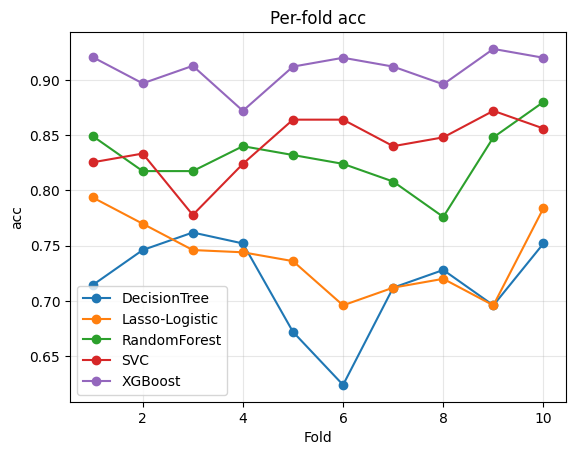

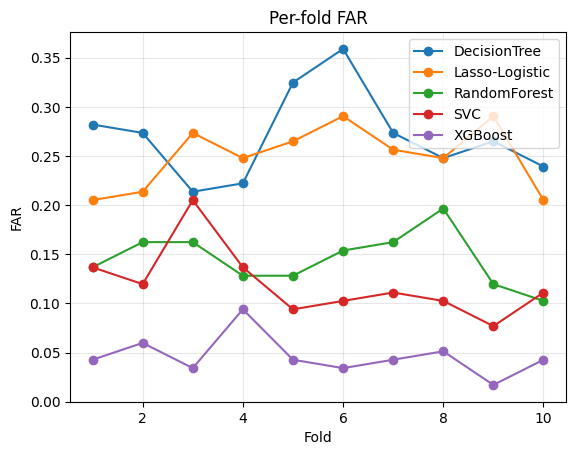

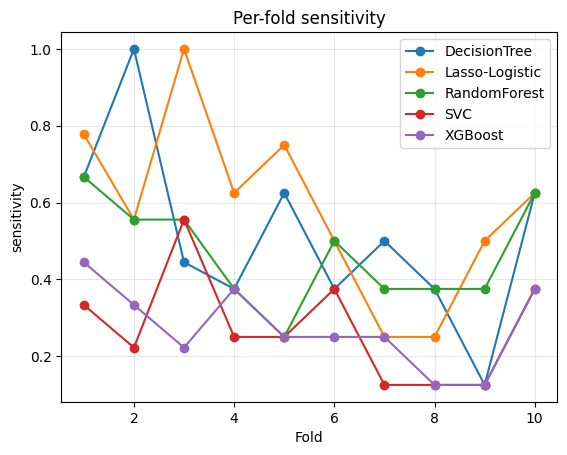

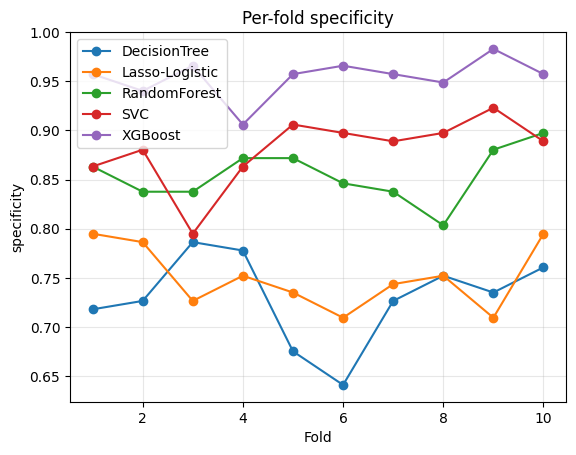

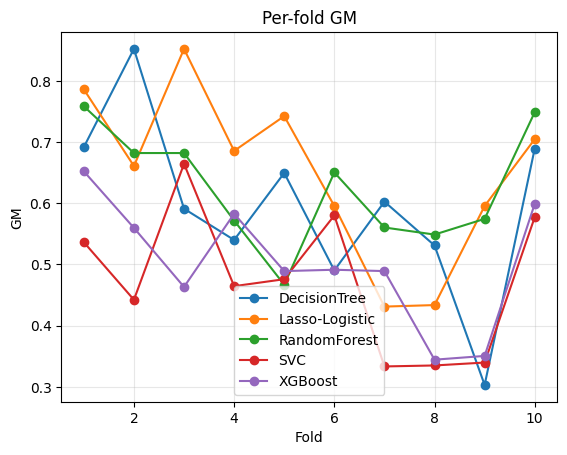

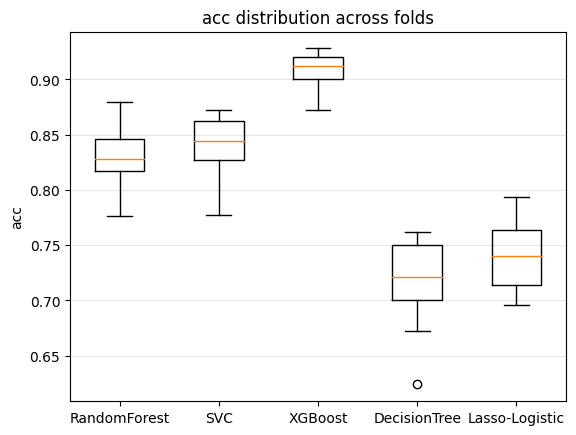

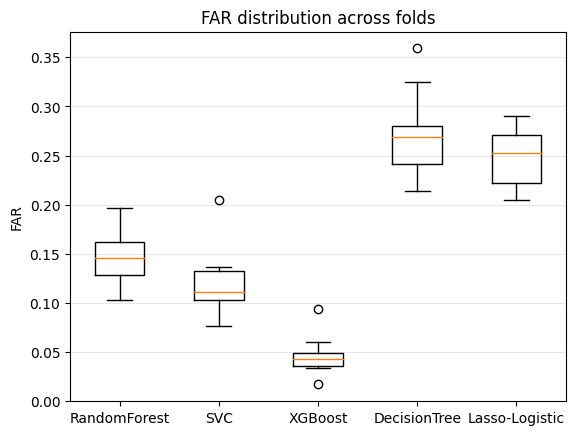

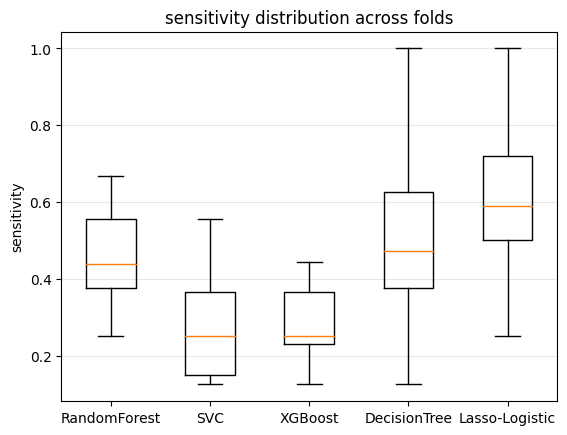

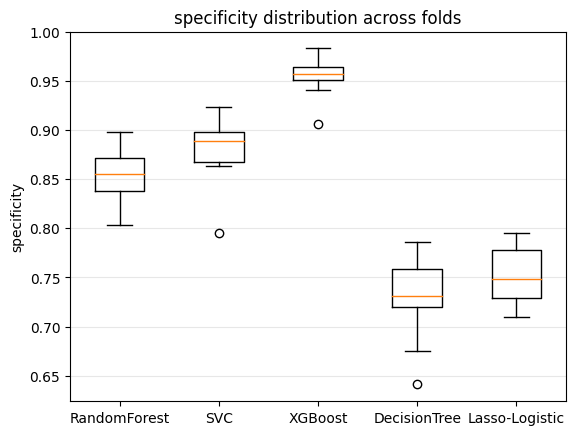

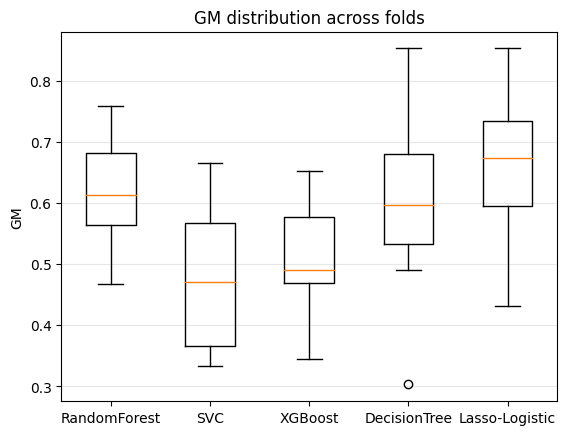


[Stability ranking] acc (by std asc)
         model      std      iqr       cv     mean
       XGBoost 0.016520 0.019381 0.018174 0.909016
           SVC 0.027647 0.034619 0.032896 0.840451
  RandomForest 0.027971 0.028540 0.033731 0.829213
Lasso-Logistic 0.034687 0.049889 0.046890 0.739752
  DecisionTree 0.042900 0.050508 0.059931 0.715822

[Stability ranking] FAR (by std asc)
         model      std      iqr       cv     mean
       XGBoost 0.020226 0.012821 0.438228 0.046154
  RandomForest 0.027327 0.034188 0.188072 0.145299
Lasso-Logistic 0.032434 0.049145 0.129957 0.249573
           SVC 0.035125 0.029915 0.293544 0.119658
  DecisionTree 0.044721 0.038462 0.165582 0.270085

[Stability ranking] sensitivity (by std asc)
         model      std      iqr       cv     mean
       XGBoost 0.106340 0.135417 0.386693 0.275000
  RandomForest 0.134379 0.180556 0.288814 0.465278
           SVC 0.138897 0.215278 0.507642 0.273611
Lasso-Logistic 0.230832 0.218750 0.395713 0.583333
  DecisionT

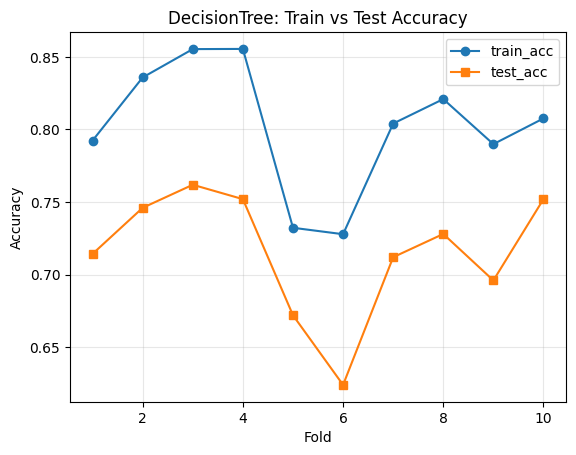

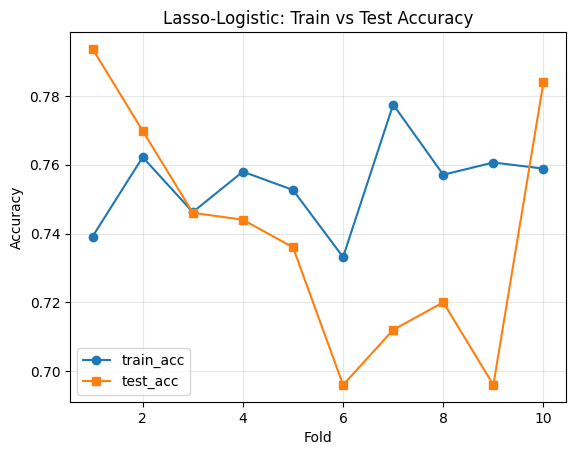

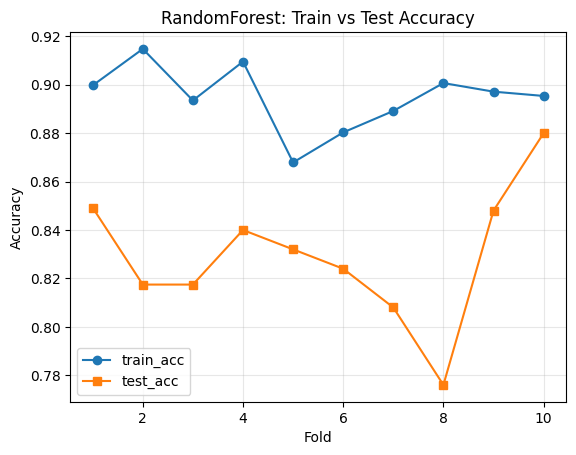

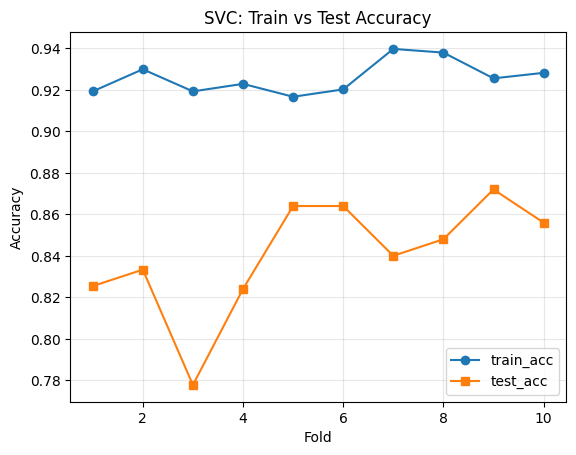

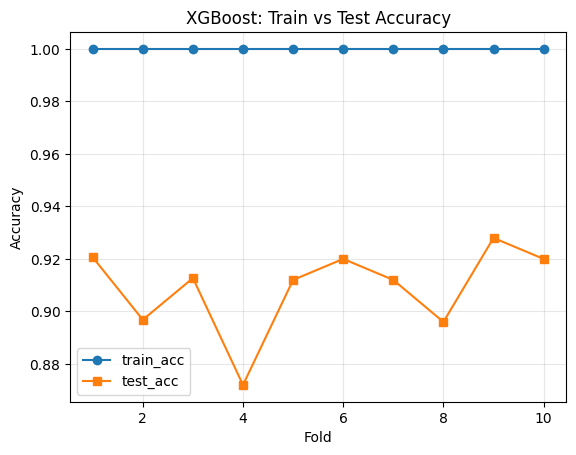

                train_acc  test_acc       gap
model                                        
XGBoost          1.000000  0.909016  0.090984
SVC              0.925955  0.840451  0.085504
RandomForest     0.894832  0.829213  0.065620
Lasso-Logistic   0.754543  0.739752  0.014791
DecisionTree     0.802171  0.715822  0.086348


In [31]:
best_feats = ranked_feats[:best_k]

X_dev_k  = X_dev[best_feats].copy()
X_test_k = X_test[best_feats].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        y_tr_hat = pipe.predict(X_tr)
        train_acc = accuracy_score(y_tr, y_tr_hat)
        y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, 'train_acc':train_acc, 'test_acc':m['acc'], **{k:m[k] for k in METRICS}})
        print(f"[{model_name}] fold={fold} train_acc={train_acc:.4f} acc={m['acc']:.4f} FAR={m['FAR']:.4f} sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    df = pd.DataFrame(fold_metrics)
    avg = {'train_acc':df['train_acc'].mean(), 'test_acc':df['test_acc'].mean(), **{k:df[k].mean() for k in METRICS}}
    gap = avg['train_acc']-avg['test_acc']
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=611211106)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=611211106)

from imblearn.pipeline import Pipeline

svc_pipe = Pipeline(steps=[('impute', knn), ('scaler', StandardScaler()), ('smote', smote), ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',class_weight='balanced', probability=False, random_state=611211106))])

xgb_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=611211106, n_jobs=-1, tree_method='hist'))])

dt_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', DecisionTreeClassifier(max_depth=6, random_state=611211106))])

logit_l1_pipe = Pipeline(steps=[('impute', knn), ('scaler', StandardScaler()), ('smote', smote), ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, class_weight='balanced', random_state=611211106))])

rfc_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=611211106, n_jobs=-1))])

models = [('RandomForest', rfc_pipe), ("SVC", svc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", logit_l1_pipe),]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_dev_k, y_dev)
    all_avg[name] = avg
    fold_dfs.append(df)
    
cv_df = pd.concat(fold_dfs, ignore_index=True)

# 1) 折線圖：每個 metric 各畫一張
for metric in METRICS:
    plt.figure()
    for name, g in cv_df.groupby('model'):
        g = g.sort_values('fold')
        plt.plot(g['fold'], g[metric], marker='o', label=name)
    plt.xlabel('Fold'); plt.ylabel(metric); plt.title(f'Per-fold {metric}')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

# 2) 盒鬚圖（快速看離散度）
for metric in METRICS:
    plt.figure()
    data = [cv_df[cv_df['model']==m][metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric} distribution across folds')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# 3) 穩定度表：std / IQR / CV（越小越穩）
stab = (cv_df
        .melt(id_vars=['model','fold'], value_vars=METRICS, var_name='metric', value_name='val')
        .groupby(['model','metric'])['val']
        .agg(std='std', iqr=lambda x: np.subtract(*np.percentile(x, [75,25])),
             mean='mean')
        .assign(cv=lambda d: d['std']/d['mean'])
        .reset_index())

# 依每個 metric 排序看最穩的模型
for metric in METRICS:
    print(f"\n[Stability ranking] {metric} (by std asc)")
    print(stab[stab['metric']==metric].sort_values('std')[['model','std','iqr','cv','mean']].to_string(index=False))

for name, g in cv_df.groupby('model'):
    g = g.sort_values('fold')
    plt.figure()
    plt.plot(g['fold'], g['train_acc'], marker='o', label='train_acc')
    plt.plot(g['fold'], g['test_acc'],  marker='s', label='test_acc')
    plt.xlabel('Fold'); plt.ylabel('Accuracy'); plt.title(f'{name}: Train vs Test Accuracy')
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

summary = (cv_df.groupby('model')[['train_acc','test_acc']]
                 .mean().assign(gap=lambda d: d['train_acc']-d['test_acc'])
                 .sort_values('test_acc', ascending=False))
print(summary)

---
---

## 各種機器學習模型, 作缺值, 相關性, KNN補值, lasso-logit特徵選擇, 在第6折的結果

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imp = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    lr = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    lr.fit(X_tr_imp, y_tr)
    coef_series = pd.Series(lr.coef_.ravel(), index=X_tr_imp.columns)
    selected = coef_series[coef_series != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imp.columns)

    scaler = StandardScaler()
    X_tr_sel = X_tr_imp[selected]
    X_te_sel = X_te_imp[selected]

    # 只對Lasso-Logit標準化
    X_tr_sel_scaled = pd.DataFrame(scaler.fit_transform(X_tr_sel), columns=selected, index=X_tr_sel.index)
    X_te_sel_scaled = pd.DataFrame(scaler.transform(X_te_sel), columns=selected, index=X_te_sel.index)

    # SMOTE（只在 train）
    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

    X_tr_sel_scaled_bal, y_tr_bal = smote.fit_resample(X_tr_sel_scaled, y_tr)
###
    train_errs_lor, test_errs_lor = [], []
    Cs = np.logspace(-3, 2, 10)
    for c in Cs:
        l1_lor = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=2000, random_state=42)
        l1_lor.fit(X_tr_sel_scaled_bal, y_tr_bal)
        
        y_train_pred_lor = l1_lor.predict(X_tr_sel_scaled_bal)
        y_pred_lor = l1_lor.predict(X_te_sel_scaled)
        cm_lr = confusion_matrix(y_te, y_pred_lor, labels=[0,1])
        tn, fp, fn, tp = cm_lr.ravel()
        acc_lor = accuracy_score(y_te, y_pred_lor)
        far_lor = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_lor.append(1-accuracy_score(y_tr_bal, y_train_pred_lor))
        test_errs_lor.append(1-accuracy_score(y_te, y_pred_lor))

    print("\n=== 第六折：L1-Logistic ===")
    print("Confusion Matrix:")
    print(cm_lr)
    print(f"Accuracy = {acc_lor:.4f}")
    print(f"False Alarm Rate = {far_lor:.4f}")
###
    lir = LinearRegression()
    lir.fit(X_tr_sel_scaled_bal, y_tr_bal)
    y_pred_lir_score = lir.predict(X_te_sel_scaled)
    y_pred_lir = (y_pred_lir_score >= 0.5).astype(int)
    cm_lir = confusion_matrix(y_te, y_pred_lir, labels=[0,1])
    tn, fp, fn, tp = cm_lir.ravel()
    acc_lir = accuracy_score(y_te, y_pred_lir)
    far_lir = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Linear Regression ===")
    print("Confusion Matrix")
    print(cm_lir)
    print(f"ACC = {acc_lir:.4f}")
    print(f"FAR = {far_lir:.4f}")
###
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sel, y_tr)

    train_errs_rf, test_errs_rf = [], []
    n_estimators_list = [10, 50, 100, 200, 500, 1000, 1800, 2000]
    for n in n_estimators_list:
        rfc = RandomForestClassifier(n_estimators=n, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
        rfc.fit(X_tr_bal, y_tr_bal)

        y_train_pred_rf = rfc.predict(X_tr_bal)
        y_pred_rf = rfc.predict(X_te_sel)
        cm_rf = confusion_matrix(y_te, y_pred_rf, labels=[0,1])
        tn, fp, fn, tp = cm_rf.ravel()
        acc_rf = accuracy_score(y_te, y_pred_rf)
        far_rf = fp/(fp+tn) if (fp+tn)>0 else np.nan
            
        train_errs_rf.append(1-accuracy_score(y_tr_bal, y_train_pred_rf))
        test_errs_rf.append(1-accuracy_score(y_te, y_pred_rf))

    print("\n=== 第六折：Random Forest ===")
    print("Confusion Matrix")
    print(cm_rf)
    print(f"ACC = {acc_rf:.4f}")
    print(f"FAR = {far_rf:.4f}")
###
    train_errs_xgbc, test_errs_xgbc = [], []
    for n in n_estimators_list:
        xgbc = XGBClassifier(objective='binary:logistic', n_estimators=n, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, eval_metric='logloss')
        xgbc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_xgbc = xgbc.predict(X_tr_bal)
        y_pred_xgbc = xgbc.predict(X_te_sel)
        cm_xgbc = confusion_matrix(y_te, y_pred_xgbc, labels=[0,1])
        tn, fp, fn, tp = cm_xgbc.ravel()
        acc_xgbc = accuracy_score(y_te, y_pred_xgbc)
        far_xgbc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_xgbc.append(1-accuracy_score(y_tr_bal, y_tr_pred_xgbc))
        test_errs_xgbc.append(1-accuracy_score(y_te, y_pred_xgbc))

    print("\n=== 第六折：xgbcoost ===")
    print("Confusion Matrix:")
    print(cm_xgbc)
    print(f"ACC = {acc_xgbc:.4f}")
    print(f"FAR = {far_xgbc:.4f}")
###
    dtc = DecisionTreeClassifier(criterion='log_loss', max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42)
    dtc.fit(X_tr_bal, y_tr_bal)

    y_pred_dtc = dtc.predict(X_te_sel)
    cm_dtc = confusion_matrix(y_te, y_pred_dtc, labels=[0,1])
    tn, fp, fn, tp = cm_dtc.ravel()
    acc_dtc = accuracy_score(y_te, y_pred_dtc)
    far_dtc = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Decision Tree ===")
    print("Confusion Matrix:")
    print(cm_dtc)
    print(f"ACC = {acc_dtc:.4f}")
    print(f"FAR = {far_dtc:.4f}")

    train_errs_svc, test_errs_svc = [], []
    Cs = np.logspace(-1, 4, 10)
    for c in Cs:
        svc = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
        svc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_svc = svc.predict(X_tr_bal)
        y_pred_svc = svc.predict(X_te_sel)
        cm_svc = confusion_matrix(y_te, y_pred_svc, labels=[0,1])
        tn, fp, fn, tp = cm_svc.ravel()
        acc_svc = accuracy_score(y_te, y_pred_svc)
        far_svc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_svc.append(1-accuracy_score(y_tr_bal, y_tr_pred_svc))
        test_errs_svc.append(1-accuracy_score(y_te, y_pred_svc))

    print("\n=== 第六折：SVC ===")
    print("Confusion Matrix:")
    print(cm_svc)
    print(f"ACC = {acc_svc:.4f}")
    print(f"FAR = {far_svc:.4f}")
    break

plt.figure(figsize=(6,4))
plt.plot(Cs, train_errs_lor, marker='o', label='Train Error')
plt.plot(Cs, test_errs_lor, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("Lasso-Logit (Fold 6)")
plt.legend()
plt.show()

plt.plot(Cs, train_errs_svc, marker='o', label='Train Error')
plt.plot(Cs, test_errs_svc, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("SVC (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_rf, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_rf, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("Random Forest (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_xgbc, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_xgbc, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("XGBoost (Fold 6)")
plt.legend()
plt.show()

---
---

## 各種機器學習模型, 作缺值, 相關性, lasso-logit特徵選擇, 中位數補值, 在第6折的結果
### ACC, FAR 差不多

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    X_tr_imp = X_tr.fillna(X_tr.median())
    X_te_imp = X_te.fillna(X_tr.median())

    lr = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    lr.fit(X_tr_imp, y_tr)
    coef_series = pd.Series(lr.coef_.ravel(), index=X_tr_imp.columns)
    selected = coef_series[coef_series != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imp.columns)

    scaler = StandardScaler()
    X_tr_sel = X_tr_imp[selected]
    X_te_sel = X_te_imp[selected]

    # 只對Lasso-Logit標準化
    X_tr_sel_scaled = pd.DataFrame(scaler.fit_transform(X_tr_sel), columns=selected, index=X_tr_sel.index)
    X_te_sel_scaled = pd.DataFrame(scaler.transform(X_te_sel), columns=selected, index=X_te_sel.index)

    # SMOTE（只在 train）
    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

    X_tr_sel_scaled_bal, y_tr_bal = smote.fit_resample(X_tr_sel_scaled, y_tr)
###
    train_errs_lor, test_errs_lor = [], []
    Cs = np.logspace(-3, 2, 10)
    for c in Cs:
        l1_lor = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=2000, random_state=42)
        l1_lor.fit(X_tr_sel_scaled_bal, y_tr_bal)
        
        y_train_pred_lor = l1_lor.predict(X_tr_sel_scaled_bal)
        y_pred_lor = l1_lor.predict(X_te_sel_scaled)
        cm_lr = confusion_matrix(y_te, y_pred_lor, labels=[0,1])
        tn, fp, fn, tp = cm_lr.ravel()
        acc_lor = accuracy_score(y_te, y_pred_lor)
        far_lor = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_lor.append(1-accuracy_score(y_tr_bal, y_train_pred_lor))
        test_errs_lor.append(1-accuracy_score(y_te, y_pred_lor))

    print("\n=== 第六折：L1-Logistic ===")
    print("Confusion Matrix:")
    print(cm_lr)
    print(f"Accuracy = {acc_lor:.4f}")
    print(f"False Alarm Rate = {far_lor:.4f}")
###
    lir = LinearRegression()
    lir.fit(X_tr_sel_scaled_bal, y_tr_bal)
    y_pred_lir_score = lir.predict(X_te_sel_scaled)
    y_pred_lir = (y_pred_lir_score >= 0.5).astype(int)
    cm_lir = confusion_matrix(y_te, y_pred_lir, labels=[0,1])
    tn, fp, fn, tp = cm_lir.ravel()
    acc_lir = accuracy_score(y_te, y_pred_lir)
    far_lir = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Linear Regression ===")
    print("Confusion Matrix")
    print(cm_lir)
    print(f"ACC = {acc_lir:.4f}")
    print(f"FAR = {far_lir:.4f}")
###
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sel, y_tr)

    train_errs_rf, test_errs_rf = [], []
    n_estimators_list = [10, 50, 100, 200, 500, 1000, 1800, 2000]
    for n in n_estimators_list:
        rfc = RandomForestClassifier(n_estimators=n, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
        rfc.fit(X_tr_bal, y_tr_bal)

        y_train_pred_rf = rfc.predict(X_tr_bal)
        y_pred_rf = rfc.predict(X_te_sel)
        cm_rf = confusion_matrix(y_te, y_pred_rf, labels=[0,1])
        tn, fp, fn, tp = cm_rf.ravel()
        acc_rf = accuracy_score(y_te, y_pred_rf)
        far_rf = fp/(fp+tn) if (fp+tn)>0 else np.nan
            
        train_errs_rf.append(1-accuracy_score(y_tr_bal, y_train_pred_rf))
        test_errs_rf.append(1-accuracy_score(y_te, y_pred_rf))

    print("\n=== 第六折：Random Forest ===")
    print("Confusion Matrix")
    print(cm_rf)
    print(f"ACC = {acc_rf:.4f}")
    print(f"FAR = {far_rf:.4f}")
###
    train_errs_xgbc, test_errs_xgbc = [], []
    for n in n_estimators_list:
        xgbc = XGBClassifier(objective='binary:logistic', n_estimators=n, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, eval_metric='logloss')
        xgbc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_xgbc = xgbc.predict(X_tr_bal)
        y_pred_xgbc = xgbc.predict(X_te_sel)
        cm_xgbc = confusion_matrix(y_te, y_pred_xgbc, labels=[0,1])
        tn, fp, fn, tp = cm_xgbc.ravel()
        acc_xgbc = accuracy_score(y_te, y_pred_xgbc)
        far_xgbc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_xgbc.append(1-accuracy_score(y_tr_bal, y_tr_pred_xgbc))
        test_errs_xgbc.append(1-accuracy_score(y_te, y_pred_xgbc))

    print("\n=== 第六折：xgbcoost ===")
    print("Confusion Matrix:")
    print(cm_xgbc)
    print(f"ACC = {acc_xgbc:.4f}")
    print(f"FAR = {far_xgbc:.4f}")
###
    dtc = DecisionTreeClassifier(criterion='log_loss', max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42)
    dtc.fit(X_tr_bal, y_tr_bal)

    y_pred_dtc = dtc.predict(X_te_sel)
    cm_dtc = confusion_matrix(y_te, y_pred_dtc, labels=[0,1])
    tn, fp, fn, tp = cm_dtc.ravel()
    acc_dtc = accuracy_score(y_te, y_pred_dtc)
    far_dtc = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Decision Tree ===")
    print("Confusion Matrix:")
    print(cm_dtc)
    print(f"ACC = {acc_dtc:.4f}")
    print(f"FAR = {far_dtc:.4f}")

    train_errs_svc, test_errs_svc = [], []
    Cs = np.logspace(-1, 4, 10)
    for c in Cs:
        svc = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
        svc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_svc = svc.predict(X_tr_bal)
        y_pred_svc = svc.predict(X_te_sel)
        cm_svc = confusion_matrix(y_te, y_pred_svc, labels=[0,1])
        tn, fp, fn, tp = cm_svc.ravel()
        acc_svc = accuracy_score(y_te, y_pred_svc)
        far_svc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_svc.append(1-accuracy_score(y_tr_bal, y_tr_pred_svc))
        test_errs_svc.append(1-accuracy_score(y_te, y_pred_svc))

    print("\n=== 第六折：SVC ===")
    print("Confusion Matrix:")
    print(cm_svc)
    print(f"ACC = {acc_svc:.4f}")
    print(f"FAR = {far_svc:.4f}")
    break

plt.figure(figsize=(6,4))
plt.plot(Cs, train_errs_lor, marker='o', label='Train Error')
plt.plot(Cs, test_errs_lor, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("Lasso-Logit (Fold 6)")
plt.legend()
plt.show()

plt.plot(Cs, train_errs_svc, marker='o', label='Train Error')
plt.plot(Cs, test_errs_svc, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("SVC (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_rf, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_rf, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("Random Forest (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_xgbc, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_xgbc, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("XGBoost (Fold 6)")
plt.legend()
plt.show()

---
---

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    X_tr_imp = X_tr.fillna(X_tr.median())
    X_te_imp = X_te.fillna(X_tr.median())

    lr = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    lr.fit(X_tr_imp, y_tr)
    coef_series = pd.Series(lr.coef_.ravel(), index=X_tr_imp.columns)
    selected = coef_series[coef_series != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imp.columns)

    scaler = StandardScaler()
    X_tr_sel = X_tr_imp[selected]
    X_te_sel = X_te_imp[selected]

    # 只對Lasso-Logit標準化
    X_tr_sel_scaled = pd.DataFrame(scaler.fit_transform(X_tr_sel), columns=selected, index=X_tr_sel.index)
    X_te_sel_scaled = pd.DataFrame(scaler.transform(X_te_sel), columns=selected, index=X_te_sel.index)

    # SMOTE（只在 train）
    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

    X_tr_sel_scaled_bal, y_tr_bal = smote.fit_resample(X_tr_sel_scaled, y_tr)
###
    train_errs_lor, test_errs_lor = [], []
    Cs = np.logspace(-3, 2, 10)
    for c in Cs:
        l1_lor = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=2000, random_state=42)
        l1_lor.fit(X_tr_sel_scaled_bal, y_tr_bal)
        
        y_train_pred_lor = l1_lor.predict(X_tr_sel_scaled_bal)
        y_pred_lor = l1_lor.predict(X_te_sel_scaled)
        cm_lr = confusion_matrix(y_te, y_pred_lor, labels=[0,1])
        tn, fp, fn, tp = cm_lr.ravel()
        acc_lor = accuracy_score(y_te, y_pred_lor)
        far_lor = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_lor.append(1-accuracy_score(y_tr_bal, y_train_pred_lor))
        test_errs_lor.append(1-accuracy_score(y_te, y_pred_lor))

    print("\n=== 第六折：L1-Logistic ===")
    print("Confusion Matrix:")
    print(cm_lr)
    print(f"Accuracy = {acc_lor:.4f}")
    print(f"False Alarm Rate = {far_lor:.4f}")
###
    lir = LinearRegression()
    lir.fit(X_tr_sel_scaled_bal, y_tr_bal)
    y_pred_lir_score = lir.predict(X_te_sel_scaled)
    y_pred_lir = (y_pred_lir_score >= 0.5).astype(int)
    cm_lir = confusion_matrix(y_te, y_pred_lir, labels=[0,1])
    tn, fp, fn, tp = cm_lir.ravel()
    acc_lir = accuracy_score(y_te, y_pred_lir)
    far_lir = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Linear Regression ===")
    print("Confusion Matrix")
    print(cm_lir)
    print(f"ACC = {acc_lir:.4f}")
    print(f"FAR = {far_lir:.4f}")
###
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sel, y_tr)

    train_errs_rf, test_errs_rf = [], []
    n_estimators_list = [10, 50, 100, 200, 500, 1000, 1800, 2000]
    for n in n_estimators_list:
        rfc = RandomForestClassifier(n_estimators=n, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
        rfc.fit(X_tr_bal, y_tr_bal)

        y_train_pred_rf = rfc.predict(X_tr_bal)
        y_pred_rf = rfc.predict(X_te_sel)
        cm_rf = confusion_matrix(y_te, y_pred_rf, labels=[0,1])
        tn, fp, fn, tp = cm_rf.ravel()
        acc_rf = accuracy_score(y_te, y_pred_rf)
        far_rf = fp/(fp+tn) if (fp+tn)>0 else np.nan
            
        train_errs_rf.append(1-accuracy_score(y_tr_bal, y_train_pred_rf))
        test_errs_rf.append(1-accuracy_score(y_te, y_pred_rf))

    print("\n=== 第六折：Random Forest ===")
    print("Confusion Matrix")
    print(cm_rf)
    print(f"ACC = {acc_rf:.4f}")
    print(f"FAR = {far_rf:.4f}")
###
    train_errs_xgbc, test_errs_xgbc = [], []
    for n in n_estimators_list:
        xgbc = XGBClassifier(objective='binary:logistic', n_estimators=n, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42, n_jobs=-1, eval_metric='logloss')
        xgbc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_xgbc = xgbc.predict(X_tr_bal)
        y_pred_xgbc = xgbc.predict(X_te_sel)
        cm_xgbc = confusion_matrix(y_te, y_pred_xgbc, labels=[0,1])
        tn, fp, fn, tp = cm_xgbc.ravel()
        acc_xgbc = accuracy_score(y_te, y_pred_xgbc)
        far_xgbc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_xgbc.append(1-accuracy_score(y_tr_bal, y_tr_pred_xgbc))
        test_errs_xgbc.append(1-accuracy_score(y_te, y_pred_xgbc))

    print("\n=== 第六折：xgbcoost ===")
    print("Confusion Matrix:")
    print(cm_xgbc)
    print(f"ACC = {acc_xgbc:.4f}")
    print(f"FAR = {far_xgbc:.4f}")
###
    dtc = DecisionTreeClassifier(criterion='log_loss', max_depth=6, min_samples_leaf=15, min_samples_split=20, random_state=42)
    dtc.fit(X_tr_bal, y_tr_bal)

    y_pred_dtc = dtc.predict(X_te_sel)
    cm_dtc = confusion_matrix(y_te, y_pred_dtc, labels=[0,1])
    tn, fp, fn, tp = cm_dtc.ravel()
    acc_dtc = accuracy_score(y_te, y_pred_dtc)
    far_dtc = fp/(fp+tn) if (fp+tn)>0 else np.nan

    print("\n=== 第六折：Decision Tree ===")
    print("Confusion Matrix:")
    print(cm_dtc)
    print(f"ACC = {acc_dtc:.4f}")
    print(f"FAR = {far_dtc:.4f}")

    train_errs_svc, test_errs_svc = [], []
    Cs = np.logspace(-1, 4, 10)
    for c in Cs:
        svc = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
        svc.fit(X_tr_bal, y_tr_bal)

        y_tr_pred_svc = svc.predict(X_tr_bal)
        y_pred_svc = svc.predict(X_te_sel)
        cm_svc = confusion_matrix(y_te, y_pred_svc, labels=[0,1])
        tn, fp, fn, tp = cm_svc.ravel()
        acc_svc = accuracy_score(y_te, y_pred_svc)
        far_svc = fp/(fp+tn) if (fp+tn)>0 else np.nan

        train_errs_svc.append(1-accuracy_score(y_tr_bal, y_tr_pred_svc))
        test_errs_svc.append(1-accuracy_score(y_te, y_pred_svc))

    print("\n=== 第六折：SVC ===")
    print("Confusion Matrix:")
    print(cm_svc)
    print(f"ACC = {acc_svc:.4f}")
    print(f"FAR = {far_svc:.4f}")
    break

plt.figure(figsize=(6,4))
plt.plot(Cs, train_errs_lor, marker='o', label='Train Error')
plt.plot(Cs, test_errs_lor, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("Lasso-Logit (Fold 6)")
plt.legend()
plt.show()

plt.plot(Cs, train_errs_svc, marker='o', label='Train Error')
plt.plot(Cs, test_errs_svc, marker='o', label='Test Error')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("SVC (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_rf, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_rf, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("Random Forest (Fold 6)")
plt.legend()
plt.show()

plt.plot(n_estimators_list, train_errs_xgbc, marker='o', label='Train Error')
plt.plot(n_estimators_list, test_errs_xgbc, marker='o', label='Test Error')
plt.xlabel("Number of Trees")
plt.ylabel("Error Rate")
plt.title("XGBoost (Fold 6)")
plt.legend()
plt.show()

---
---

## 在第6折, 以logit regression的MLE+梯度下降法計算x的$\hat{\beta}$, 並依照絕對值遞減排列

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imputed, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    scaler = StandardScaler()
    X_tr_std = pd.DataFrame(scaler.fit_transform(X_tr_imputed), columns=X_tr_imputed.columns, index=X_tr_imputed.index)
    X_te_std = pd.DataFrame(scaler.fit_transform(X_te_imputed), columns=X_te_imputed.columns, index=X_te_imputed.index)

    X_tr_sel = X_tr_std[selected]
    X_te_sel = X_te_std[selected]

    print(f'[L1-Logit] 篩到 {X_tr_sel.shape[1]} 個特徵')
    print(selected)

    # 以梯度下降（無正則）估計 Logit 係數
    # 目標：最小化平均負對數似然
    # p = sigmoid(Xb)，X 需含截距
    n, p = X_tr_sel.shape
    X_gd = np.hstack([np.ones((n, 1)), X_tr_sel])  # 加截距
    X_te_gd = np.hstack([np.ones((X_te_sel.shape[0], 1)), X_te_sel])
    beta = np.zeros(p+1)

    def _sigmoid(z):
        return 1.0/(1.0+np.exp(-z))

    # 超參數
    learning_r = 0.05
    max_iter = 500000
    tol = 1e-6
    loss_hist = []
    te_loss_hist = []
    # prev_loss = np.inf
    best_te_loss = np.inf
    best_beta = beta.copy()
    best_it = 0
    patience, noimp = 50, 0
    for it in range(1, max_iter+1):
        z = X_gd@beta
        z_te = X_te_gd @ beta
        
        p_hat = 1.0/(1.0+np.exp(-z))
        p_te_hat = 1.0/(1.0+np.exp(-z_te))

        loss = -np.mean(y_tr*np.log(p_hat)+(1-y_tr)*np.log(1-p_hat))
        te_loss = -np.mean(y_te*np.log(p_te_hat)+(1-y_te)*np.log(1-p_te_hat))

        grad = X_gd.T@(p_hat-y_tr)/n
        beta -= learning_r*grad
        loss_hist.append(loss)
        te_loss_hist.append(te_loss)

        if te_loss<best_te_loss-(1e-6):
            best_te_loss = te_loss
            best_beta = beta.copy()
            best_it = it
            noimp = 0
        else:
            noimp += 1
            if noimp >= patience:
                break
    beta = best_beta
    print(f'[EarlyStop] best_iter={best_it}, best_val_loss={best_te_loss:.6f}')            

        # if abs(prev_loss-loss)<1e-6:
        #     break
        # prev_loss = loss

    # print(f'[GD-Logit] 迭代次數: {it}, 最終 loss: {loss:.6f}')
    # print('[GD-Logit] 截距(beta0):', float(beta[0]))

    beta_df = pd.DataFrame({'feature': selected, 'beta_gd': beta[1:]}).sort_values('beta_gd', key=np.abs, ascending=False)
    pd.set_option('display.max_rows', None)


    break

In [ ]:
plt.plot(range(1, len(loss_hist)+1), loss_hist, label='tr')
plt.plot(range(1,len(te_loss_hist)+1), te_loss_hist, label='te')
plt.legend()
print(beta_df.head())

### LinAlgError: Singular matrix

In [ ]:
# X_sm = sm.add_constant(X_tr_sel)
# res = sm.Logit(y_tr, X_sm).fit(disp=0)
# print(res.summary())  

---
---